<h1 style="font-family: Arial; font-weight: 900; color: magenta; text-align: center;">REGRESSION ANALYSIS</h1><br>

<br/><div style="font-family: Arial; color: darkblue; font-size: 14px; font-weight: 600"><a id="toc"></a>
In this part 9:
    <p style="margin: 0 0 0 2rem; font-size: 16px; font-weight: 800">[1. Exploring the Ames housing dataset](#1)</p>
        <p style="margin: 0 0 0 4rem">[1a. Visualizing important characteristics of a dataset](#1a)</p>
        <p style="margin: 0 0 0 4rem">[1b. The correlation matrix](#1b)</p><br/>
    <p style="margin: 0 0 0 2rem; font-size: 16px; font-weight: 800">[2. Linear regression with gradient descent](#2)</p>
        <p style="margin: 0 0 0 4rem">[2a. A basic implementation of GD](#2a)</p>
        <p style="margin: 0 0 0 4rem">[2b. Scikit-learn's 'LinearRegression'](#2b)</p>
        <p style="margin: 0 0 0 4rem">[2c. Quantitative evaluations of a model](#2c)</p>
        <p style="margin: 0 0 0 4rem">[2d. Regularized linear regression](#2d)</p>
        <p style="margin: 0 0 0 4rem">[2e. Polynomial regression](#2e)</p><br/>
    <p style="margin: 0 0 0 2rem; font-size: 16px; font-weight: 800">[3. Non-linear regression models](#3)</p>
        <p style="margin: 0 0 0 4rem">[3a. Non-linear relationships with decision trees](#3a)</p>
        <p style="margin: 0 0 0 4rem">[3b. Non-linear relationships with random forests](#3b)</p></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The datasets we will use : ("columns" and the dataset will be defined in cell 2)
# df_housing = pd.read_csv("AmesHousing.txt", sep="\t", usecols=columns)

from colorama import Fore, Back, Style
# define some strings for cleaner codes
BB = Fore.BLUE + Style.BRIGHT
MB = Fore.MAGENTA + Style.BRIGHT

# Styling function to beautify the dataframes
def beautify(df):
    # df.style creates a Styler object from the DataFrame df, which allows styling to be applied to the
    # dataframe's representation; then 'set_table_styles' applies css styling (eg 'text-align: center')
    # to the table header cells (<th>) and data cells (<td>) of the dataframe
    styled_df = df.style.set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('color', 'blue')]}, 
        {'selector': 'td', 'props': [('text-align', 'center'), ('color', 'magenta'), ('font-weight', 'bold')]}])    
    # The Styler object resets the precision of floats to 6 decimal places, whatever their original format; only
    # the display is affected, though, not the original data; here, the floats are float64 numbers and correspond
    # to data which are integers in disguise, so I reformat their display to 2 decimal places
    return styled_df.format({col: '{:.2f}'.format for col in df.select_dtypes(include=['float64'])})

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        In binary classification tasks, linear estimations have been used to estimate the logit of the probability that an instance $x$ belongs to class $1$; this was the basis of the logistic regression classifiers (see part 3, "2. Logistic regression").<br>$\quad$
        When the variable $y$ that we want to predict is continuous, we may again use linear estimations; we try to predict the value of $y$ by using a linear combination of features $X_1$,...,$X_n$, meaning that if an example $x$ has values $x_1$,...,$x_n$ on these features, then the predicted value for the corresponding $y$ will be<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$\hat{y} \;=\; \sum_{j=1}^n \, w_{j} \, x_j \,+\, b \;=\; w.x \,+\, b \qquad (1)$$</font>
    where $\,b \in \mathbb{R}b\,$ and $\,w=\left(w_j\right)_{j=1}^n \in \mathbb{R}^n\,$ are again called the <font color='darkpink'>bias</font> and the <font color='darkpink'>weight</font> of the model.<br>$\quad$
        The goal is thus to determine the values of $b$ and $w$ which minimize the errors, or, more precisely, which minimize a cost function whose values depend on the sizes of the errors. The cost function of choice in regression analysis is the <font color='darkpink'>Mean Squared Error<br><p style="margin: 0 0 .5rem 0"></p>
        $$MSE \;:=\; \frac{1}{m} \, \sum_{i=1}^m \left( y^{(i)} - \hat{y}^{(i)} \right)^2 \qquad (2)$$</font>
    where the $\;y^{(i)},\, i=1,\cdots,n\;$ are the true values corresponding to the instances $\;x^{(i)},\, i=1,\cdots,n\;$ and the $\;\hat{y}^{(i)},\, i=1,\cdots,n\;$ are their linear predictions.<br>$\quad$
        Other cost functions may be used, eg the Mean Absolute Error :<br><p style="margin: 0 0 .5rem 0"></p><font color='darkpink'>
        $$MAE(b,w) \;:=\; \frac{1}{m} \, \sum_{i=1}^m \left| y^{(i)} - \hat{y}^{(i)} \right| \qquad (3)$$</font>$\quad$
        Like in the classification case, we may also use regularized cost functions in order to avoid overfitting.<br>$\quad$
        In classification tasks we evaluate the quality of a model via accuracy scores and other classification metrics, while the $MSE\,$ is merely the cost function that we want to minimize. In regression tasks, the variable to predict is continuous, there are no classes to predict, so other metrics are necessary; the cost function (usually the $MSE\,$) is used not only to train the models but also to evaluate them (we will see a slight variation in "2c. Quantitative evaluations of a model").<br><br>$\quad$
        In this part we will introduce a new dataset, together with new techniques to visualize a dataset before modelization. We will then modelize the dataset with a basic linear regression. Then we will use a regularized function to improve our results on the test dataset. We will generalize the model to polynomial regression. In the last chapter, we will introduce random forests regression, which can modelize nonlinear relationships.

<a id="1"></a><br><br><br><div style="font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">
    <h4 style="margin: 0 0 .5rem 2rem; font-size: 18px; font-weight: 800"><font color='darkpink'>1. EXPLORING THE AMES HOUSING DATASET</font></h4>
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>1a. Visualizing important characteristics of a dataset</font><a id="1a"></a></p>$\quad$
        The Ames housing dataset contains information about individual residential property in Ames, Iowa, from 2006 to 2010. It consists of 2,930 examples and 80 features. For simplicity, we will only
work with the following small subset of features :<br>
    * <font color='purple'>Overall Qual</font> (overall quality) : rating for the overall material and finish of the house on a scale from 1 (very poor) to 10 (excellent)<br>
    * <font color='purple'>Overall Cond</font> (overall condition) : rating for the overall condition of the house on a scale from 1 (very poor) to 10 (excellent)<br>
    * <font color='purple'>Gr Liv Area</font> : above grade (ground) living area in square feet (I am sorry for using these retarded units, I'm just using the dataset used in the book; 100sqft $\approx$ 9.29m²)<br>
    * <font color='purple'>Central Air</font> : central air conditioning (Y=yes, N=no)<br>
    * <font color='purple'>Total Bsmt SF</font> : total square feet of the basement area<br>
    * <font color='purple'>SalePrice</font> : sale price in U.S. dollars ("$\$$")<br>$\quad$
        For the rest of this chapter, we will consider the sale price (SalePrice) as our target variable, ie the variable that we want to predict using one or more of the five other variables. But before we explore this dataset further, let’s load it into a <font color='green'>pandas</font> DataFrame and take a look at the kind of data it holds :

In [2]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']
# 1. I have downloaded the text file from the author's Github and put it in my summary's folder, but
# it is also possible to use it directly from the internet, using
# df_housing = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousingAmesHousing.txt', sep='\t',
# usecols=columns)
# 2. while in the book it is called "df" I prefer to call it "df_housing"
# 3. 'sep="\t" asks pandas to split the lines of the file into columns based on the tab characters
df_housing = pd.read_csv("AmesHousing.txt", sep="\t", usecols=columns)
print(BB + "The head of the initial 'df_housing' dataframe :\n")
beautify(df_housing.head())

The head of the initial 'df_housing' dataframe :



,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.00,Y,1656,215000
1,5,6,882.00,Y,896,105000
2,6,6,1329.00,Y,1329,172000
3,7,5,2110.00,Y,2110,244000
4,5,5,928.00,Y,1629,189900


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        We should first check whether any of the data frame columns contain missing values :

In [3]:
# Convert the sum of NaN values per column to a DataFrame
nan_count_df = df_housing.isnull().sum().to_frame()
# Rename the column to "nb_NaN"
nan_count_df.columns = ['nb_NaN']

print(BB + "The number of NaN in each column of the df_housing dataframe :")
# Apply our 'beautify' function (from cell 1) to render the dataframe
beautify(nan_count_df)

The number of NaN in each column of the df_housing dataframe :


,nb_NaN
Overall Qual,0
Overall Cond,0
Total Bsmt SF,1
Central Air,0
Gr Liv Area,0
SalePrice,0


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Linear regression models can not deal with missing data or non-numerical values, so we need to remove the instance with the missing value from the dataset, and replace the "N" and the "Y" in the "Central Air" column with $0$ and $1$ (quite arbitrarily, I admit 😉) :

In [4]:
# drops the rows of df_housing which contains a NaN in one of their columns
df_housing = df_housing.dropna(axis=0)
# replaces "N" by 0 and "Y" by 1 in the "Central Air" column of df_housing
df_housing["Central Air"] = df_housing["Central Air"].map({"N": 0, "Y": 1})

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        We can now check that the dataframe is ready for regression analysis :

In [5]:
print(BB + "The head of the 'df_housing' dataframe, once corrected :\n")

# Apply our 'beautify' function to render the dataframe's head
beautify(df_housing.head())

The head of the 'df_housing' dataframe, once corrected :



,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.00,1,1656,215000
1,5,6,882.00,1,896,105000
2,6,6,1329.00,1,1329,172000
3,7,5,2110.00,1,2110,244000
4,5,5,928.00,1,1629,189900


In [6]:
# Convert the sum of NaN values per column to a DataFrame
nan_count_df = df_housing.isnull().sum().to_frame()
# Rename the column to "nb_NaN"
nan_count_df.columns = ['nb_NaN']

print(BB + "The number of NaN in each column in the corrected df_housing dataframe :")
# Apply our 'beautify' function (from cell 1) to render the dataframe
beautify(nan_count_df)

The number of NaN in each column in the corrected df_housing dataframe :


,nb_NaN
Overall Qual,0
Overall Cond,0
Total Bsmt SF,0
Central Air,0
Gr Liv Area,0
SalePrice,0


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        And now, we plot the one-to-one relationships of the various features. One such plot is called a <font color='darkpink'>scatter plot</font>, and the whole set of them is called the <font color='darkpink'>scatter plot matrix</font>.<br>$\quad$
        To plot the scatter plot matrix, and below to plot the correlation matrix, the book uses the "<font color='green'>mlxtend</font>" library (<font color='cyan'>http://rasbt.github.io/mlxtend/</font>), instead of the more widely used <font color='green'>seaborn</font> library. The scatter plot matrix offered by <font color='green'>mlxtend</font> is better, especially the histograms, where the <font color='green'>seaborn</font>'s scalings are inadequate. But the correlation matrix offered by <font color='green'>mlxtend</font> is not clear (dark texts over dark backgrounds), while <font color='green'>seaborn</font>'s correlation matrix is nice. So, here, I will use both libraries.<br>$\quad$
        To download <font color='green'>mlxtend</font>, enter <font color='violet'>pip install mlxtend</font> or <font color='violet'>conda install mlxtend</font> in your console. To download <font color='green'>seaborn</font>, do the same (but replace <font color='violet'>mlxtend</font> with <font color='violet'>seaborn</font> 😉)<br>$\quad$
        To get a scatter plot with <font color='green'>mlxtend</font>, use their <font color='green'>scatterplotmatrix</font> function :

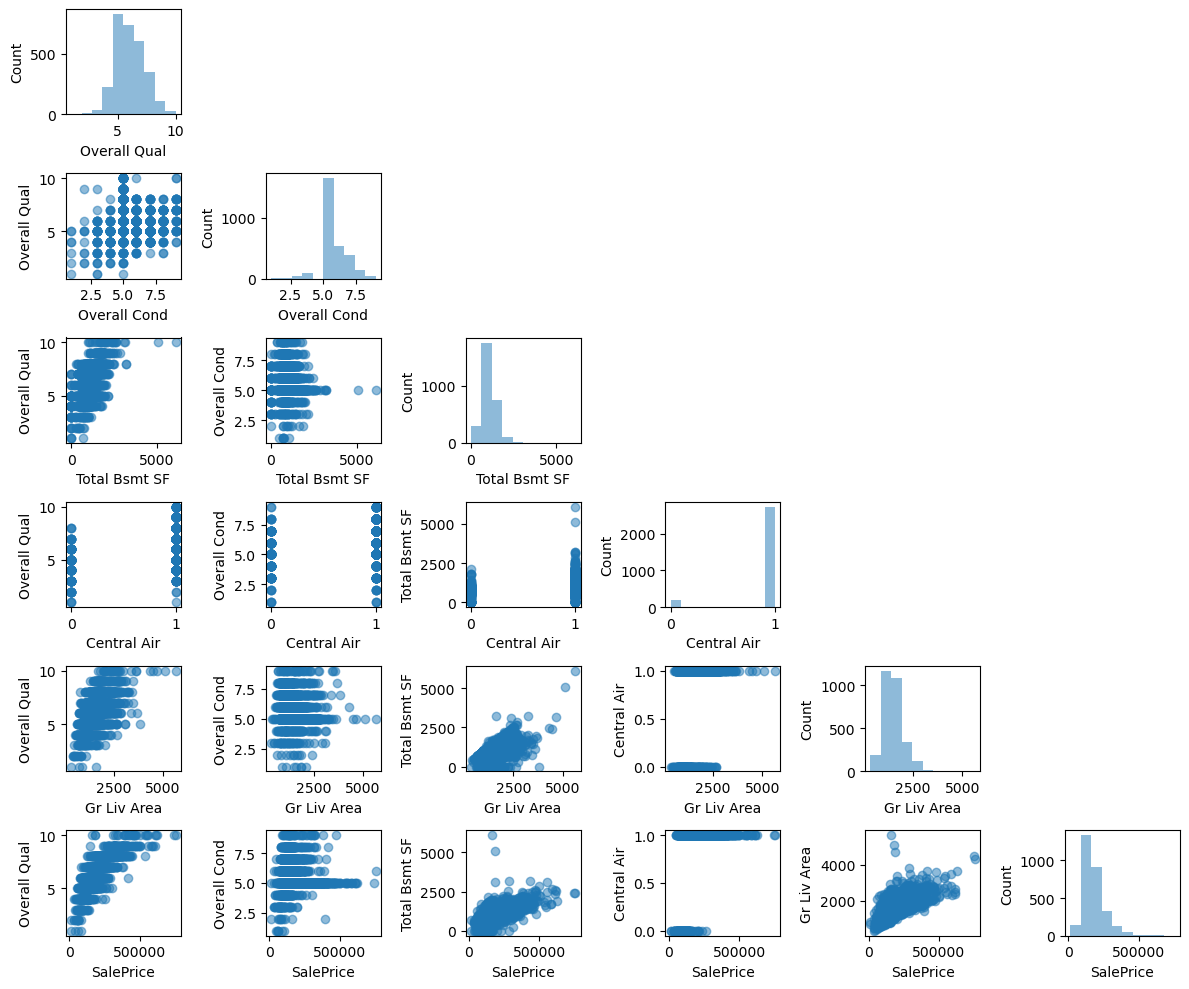

In [7]:
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df_housing.values, figsize=(12,10), names=df_housing.columns, alpha=0.5)
plt.tight_layout()
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Using this scatter plot matrix, we can now quickly see how the data is distributed and whether it contains outliers. For example, we can see fifth column from the left of the bottom row) that there is a somewhat linear relationship between the size of the living area above ground ("Gr Liv Area") and the sale price ("SalePrice"). Furthermore, we can see in the SalePrice's histogram (the lower-right subplot in the scatterplot matrix) that the SalePrice variable may be skewed by several outliers (a few houses are in a category of their own regarding their price).

<br><br><div style="font-family: Arial; font-size:14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>1b. The correlation matrix</font><a id="1b"></a></p>$\quad$
        Let's briefly return to a general presentation. We first remind our dear reader of the basic definitions and notations we have used in the previous parts when studying classification problems, in order to present Pearson's correlation coefficient unambiguously.<br>$\quad$
        Our training data is represented in a matrix $\;X \in \mathbb{R}^{m \times n}\;$; its columns are called the features, and denoted by $X_1$,...,$X_n$. To any of these features, $X_p$, $p\in{1,\cdots,n}\,$ we associate :<br>
* the <font color='purple'>mean</font> :<br><font color = 'purple'>
        $$\mu_p \;=\; \frac{1}{m} \, \sum_{i=1}^m \, x_{ip} \qquad (4)$$</font>
* the <font color='purple'>variance</font> :<br><font color = 'purple'>
        $$\text{Var}(X_p) \;=\; \frac{1}{m} \, \sum_{i=1}^m \, \left(x_{ip}-\mu_p\right)^2 \qquad (5)$$</font>
* the <font color='purple'>standard deviation</font> :<br><font color = 'purple'>
        $$\sigma_p \;=\; \sqrt{\text{Var}(X_p)} \qquad (6)$$</font><br>
* and the <font color='darkpink'>corresponding standardized feature</font> :<br><p style="margin: 0 0 .5rem 0"></p><font color = 'darkpink'>
        $$X_p^{(s)}\,=\,\left(x_{ip}^{(s)}\right)_{i=1}^m \qquad \text{where} \quad \forall i=1,\cdots,m \qquad x_{ip}^{(s)} \,=\, \frac{x_{ip} - \mu_p}{\sigma_p} \qquad (7)$$<font color = 'darkpink'><br>
    These standardized features have mean $0$ and variance (and standard deviation) $1$.

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        We continue with some usual definitions and notations.<br>$\quad$
        The <font color='purple'>covariance</font> of any two features $X_p$ and $X_q$, $\;p,q \in \{1,\cdots,n\}\,$ is the real number<br><p style="margin: 0 0 .5rem 0"></p><font color = 'purple'>
        $$\text{Cov}\left(X_p,X_q\right) \;=\; \frac{1}{m} \, \sum_{i=1}^m \, \left(x_{ip}-\mu_p\right) \left(x_{iq}-\mu_q\right) \qquad (8)$$</font>
        The <font color='purple'>covariance matrix</font> of the features $X_1$,...,$X_n$ is the matrix<br><p style="margin: 0 0 .5rem 0"></p><font color = 'purple'>
        $$\text{Cov}\left(X_1,\cdots,X_n\right) \;=\; \left(\text{Cov}\left(X_p,X_q\right)\right)_{p,q=1}^n \qquad (9)$$</font><br>$\quad$
        Using the notations above, we call <font color='darkpink'>correlation matrix</font> (of the features $X_1$,...,$X_n$) the covariance matrix of their standardized versions :<br><p style="margin: 0 0 .5rem 0"></p><font color = 'darkpink'>
        $$\text{Cov}\left(X_1^{(s)},\cdots,X_n^{(s)}\right) \;=\; \left(\text{Cov}\left(X_p^{(s)},X_q^{(s)}\right)\right)_{p,q=1}^n \;=\; \left(\frac{\text{Cov}(X_p,X_q)}{\sigma_p\;\sigma_q}\right)_{p,q=1}^n \qquad (10)$$</font><br>$\quad$
        For any $p$ and $q$ in $\{1,\cdots,n\}$, the coefficient $\,\text{Cov}\left(X_p^{(s)},X_q^{(s)}\right)\,$ is called the <font color = 'darkpink'>Pearson's correlation coefficient between $X_p$ and $X_q$</font>. It measures their linear dependence, and its value lies in $\left[-1,1\right]$. $X_p$ and $X_q$ have a perfect positive correlation if $\,\text{Cov}(X_p^{(s)},X_q^{(s)})=1\,$, no correlation if $\,\text{Cov}(X_p^{(s)},X_q^{(s)})=0\,$, and a perfect negative correlation if $\,\text{Cov}(X_p^{(s)},X_q^{(s)})=-1\,$.

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        In the following code example, we will use <font color='green'>NumPy</font>’s '<font color='green'>corrcoef</font>' function on the five feature columns that we previously visualized in the scatterplot matrix, and we will use <font color='green'>seaborn</font>’s heatmap function to plot the correlation matrix array as a <font color='darkpink'>heat map</font> (a heat map is a graphical colorful representation of the values in a matrix) :

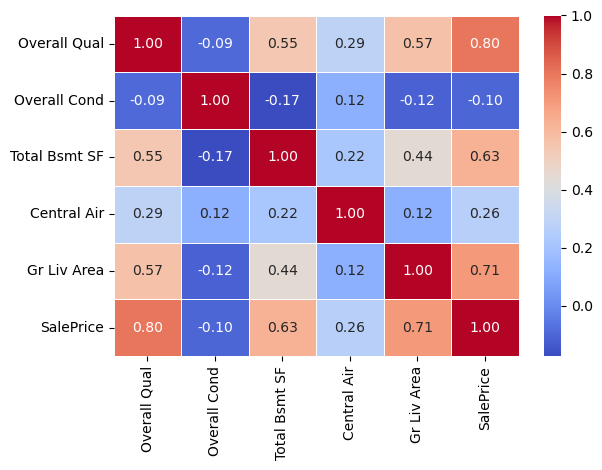

In [8]:
from seaborn import heatmap

# the '.values' attribute of a DataFrame extracts its values and places them in a numpy array
# then '.T' transposes the array
# and 'np.corrcoef' computes the correlation coefficients of the rows of its argument
# therefore 'cm' is the correlation matrix of the df_housing's features
cm = np.corrcoef(df_housing.values.T)  # Compute correlation matrix
heatmap(cm, annot=True, fmt=".2f", xticklabels=df_housing.columns, 
            yticklabels=df_housing.columns, cmap='coolwarm', linewidths=0.5)
# adjusts the layout of the plot to ensure that all elements fit within the figure area without
# overlapping
plt.tight_layout()
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        "To fit a linear regression model, we are interested in those features that have a high correlation with our target variable, 'SalePrice'. Looking at the previous correlation matrix, we can see that 'SalePrice' [is the continuous variable which] shows the largest correlation with the 'Gr Liv Area' variable ($0.71$), which seems to be a good choice for an exploratory variable to introduce the concepts of a simple linear regression model in the following section." 'SalePrice' has an even greater correlation with 'Overall Qual' ($0.80$), but since 'Overall Qual' is not continuous, we cannot perform a linear regression with it, which is the primary goal of the following chapter.

<a id="2"></a><br><br><br><div style="font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">
    <h4 style="margin: 0 0 .5rem 2rem; font-size: 18px; font-weight: 800"><font color='darkpink'>2. LINEAR REGRESSION WITH GRADIENT DESCENT</font></h4>
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>2a. A basic implementation of GD</font><a id="2a"></a></p>$\quad$
        We had already implemented a gradient descent for the $MSE\,$ when we studied Adaline (see part 2, "3. Adaline" for Adaline, and "3b. Adaline with the batch gradient descent" for our code), we can simply copy/paste the code without applying the threshold function at the end :

In [9]:
class LinearRegressionGD:
    """Our first linear regression model
    
    Parameters
    ------------
    eta : the learning rate (a float between 0.0 and 1.0)
    n_iter : the number of passes over the training dataset (an int)
    random_state : a random number generator seed for random weight initialization (an int)
    
    Attributes
    -----------
    w_ : the weight vector (a 1d-array of floats)
    b_ : the bias (a float)
    losses_ : the MSE value at each epoch (a 1d array of floats)
    """
    
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        """ Fit training data :
        Parameters
        ----------
        X : the training matrix, of shape n_examples*n_features
        y : the target vector, of length n_examples
        Returns
        -------
        self : object """

        # 'rgen = np.random.RandomState(self.random_state)' was the original line of code; I use the
        # modern way (according to chatGPT) instead
        # 'rgen' will be a random number generator object, defined via NumPy's 'default_rng' function
        # which requires a seed value to initialize the RNG ('self.random_state'), determining the
        # sequence of random numbers generated by the RNG
        rgen = np.random.default_rng(self.random_state)
        # generates an array of random numbers drawn from a normal distribution with a mean (loc) of
        # 0 and a standard deviation (scale) of 0.01. The number of random numbers to generate is
        # 'X.shape[1]', ie the number of features in X; thus, each random number generated represents
        # an initial weight value for a feature in a machine learning model
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # initializes the bias term 'self.b_' of the linear regression model to zero
        self.b_ = np.float_(0.)
        # initializes an empty list ('self.losses_') to store the square of the errors between the
        # actual target values (y) and the predicted value ('output') of the model
        self.losses_ = []
        # 'self.n_iter' is the number of epochs
        for i in range(self.n_iter):
            # 'self.net_input(X)' is the estimated value for the set of instances
            output = self.net_input(X)
            errors = (y - output)
            # updates the weights in the case of the MSE, using gradient descent (for a general
            # explanation see part 2, "2. Linear and polynomial regression", and for this particular
            # equation, see "2c. The batch gradient descent (BGD)" in the same chapter
            self.w_ += self.eta * 2.0 * X.T @ errors / X.shape[0]
            # update the bias using the same equation (but the first column of 'X' is composed of 1)
            self.b_ += self.eta * 2.0 * errors.mean()
            # computes the MSE
            loss = (errors**2).mean()
            # appends it to 'self.losses_', so it keeps track of the evolution of the MSE
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        # returns the estimated values of the instances
        return X @ self.w_ + self.b_

    def predict(self, X):
        # (chatGPT:) It's common practice in machine learning libraries to provide a separate
        # 'predict' method as a more user-friendly interface for making predictions
        return self.net_input(X)

<div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
<p style="margin: 0 0 0 2rem; font-size: 15px; font-weight: 600"><font color='purple'>$\quad$Note :</font></p> $\quad$
        <font color='darkpink'>If the training matrix and the target vector are standardized then, whenever we stop this code, the bias will be $0$</font>. Indeed, it is initialized as $0$, and then, if it has value $0$ at epoch $k$ then its new value is ($0$ plus) 'self.eta * 2.0 * errors.mean()', so it still $0$ iff the mean of the errors is $0$. But if we denote by $w^{(k)}$ and $b^{(k)}$ the weight vector and the bias after $k$ epochs, then the vector of the errors at epoch $(k+1)$ is $\,\left[y-(Xw^{(k)}+b^{(k)}\mathbf{1})\right]\,$ where $\mathbf{1}$ is the column vector of dimension $m$ whose components are all $1$. Since $b^{(k)}=0$ by hypothesis the vector of errors at epoch $(k+1)$ is $\,\left[y-Xw^{(k)}\right]\,$; denoting by $X_1$,...,$X_n$ the features of $X$, and by $\,w_j^{(k)}, j=1,\cdots,n\,$ the components of $w^{(k)}$, the vector of errors at epoch $(k+1)$ may also be written $\,\left[y-\sum_{j=1}^n w_j^{(k)}X_j\right]\,$. But since the features and the target vector have been standardized by hypothesis, the mean of this vector is $0$, qed.<br><br>$\quad$
        Let's try our code in an attempt to linearly estimate 'SalePrice' from 'Gr Liv Area' and check how fast it converges (in number of epochs) :

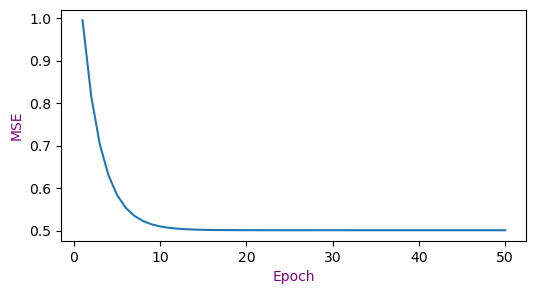

In [10]:
# takes the feature 'Gr Liv Area' from df_housing and converts it into a 2d array, as is usually the
# case for a set of features (here reduced to 1 feature only)
X = df_housing[['Gr Liv Area']].values
# takes the feature 'SalePrice' from df_housing and converts it into a 1d-array, as is usually the
# case for a target vector
y = df_housing['SalePrice'].values

# 'StandardScaler()' is the scikit-learn class which standardizes a set of features (2d-array), one
# feature at a time
from sklearn.preprocessing import StandardScaler
# we create one object to standardize 'X' and another to standardize 'y'
sc_x = StandardScaler()
sc_y = StandardScaler()
# X_std is the standardized version of 'X'
X_std = sc_x.fit_transform(X)
# 'y' is a column, hence a 1d-array, so it can not be standardized with 'StandardScaler()'; therefore
# we first transform it into a 2d-array; 'y[:, np.newaxis]' is the 2d-array obtained from 'y' by
# transforming each one of its values (eg p), into a row ([p]). Then it can be standardized (ie its
# first and only column is standardized). At last, '.flatten' transforms any 2d-array of dim m by n
# into a row of length (mn) by copying its first row (from left to right), then its second, etc.;
# since we have a single column the result is a row of length the length of the column
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()
# creates an object of our own class 'LinearRegressionGD'
lr = LinearRegressionGD(eta=0.1)
# uses its 'fit' method to generate a sequence of 50 epochs of gradient descent and store the
# evolution of the MSE
lr.fit(X_std, y_std)

# creates a new figure for plotting with a size of 6 by 3 inches (when the size of the support
# allows it, otherwise it will be scaled down to be displayed entirely)
plt.figure(figsize=(6,3))
# plots the evolution of the MSE over the epochs, ranging from 1 to the total number of iterations
plt.plot(range(1, lr.n_iter+1), lr.losses_)
# sets the labels for the x and y axes
plt.xlabel('Epoch', color='purple')
plt.ylabel('MSE', color='purple')
# displays the plot on the screen
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        We can see that the error first decreases and then stays approximately the same after the 13th epoch, so we could use our 'LinearRegressionGD' class with 'n_iter' = 13 instead of 50 in this case.<br>$\quad$
        Anyway, now that it has been trained (with 50 epochs), let's see how well the best straight line depending only on the living area above ground does approximate the sale prices :

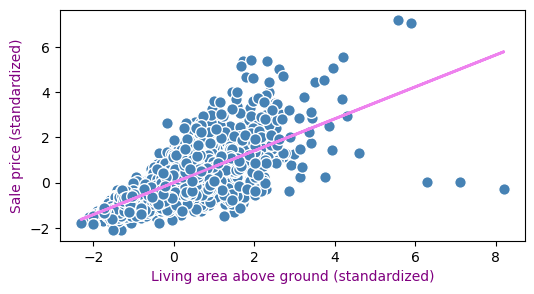

In [11]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='violet', lw=2)
plt.figure(figsize=(6,3))
lin_regplot(X_std, y_std, lr)
plt.xlabel("Living area above ground (standardized)", color='purple')
plt.ylabel("Sale price (standardized)", color='purple')
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        We can see that the sale prices tend to increase with the living area above ground, as expected, but that the living area is not enough to estimate a sale price with accuracy. There are even 3 outliers which occupy the largest areas but are not expensive at all compared to other housings.<br>$\quad$
        Also, as I have already mentioned below the code for the 'LinearRegressionGD' class (cell 9), since we had standardized the features and the target, our bias here is $0$. The slope is the weight, so the equation of the linear regression line is :

In [12]:
a = str(round(lr.w_[0],3))
b = str(round(lr.b_,3))
print(BB + "In the standardized case, the linear regression line has equation :" + MB +\
      " y = " + a + "x + " + b)

In the standardized case, the linear regression line has equation : y = 0.707x + -0.0


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Since we had standardized the target vector, the sale prices are not real prices anymore; to get the estimated price once the standardized estimation has been made we use the <font color='green'>inverse_transform</font> method of <font color='green'>StandardScaler</font>. For example, suppose we want to estimate the sale price of a housing with a living area above ground of $2,500$ sqft, then we can do as follows :

In [13]:
# the first step is to apply to our parameter the same transformation as the one we used to standardize
# our initial feature vector, ie with the fitted 'sc_x'; '2500' must be placed in a 2d-array, since it
# is the type of arguments expected by scikit-learn's 'transform' method
feature_std = sc_x.transform(np.array([[2500]]))
# then we can apply the 'predict' method of our 'LinearRegressionGD' class
target_std = lr.predict(feature_std)
# and now we need to apply the inverse of the transformation we used to standardize the target vector
# by using the 'inverse_transform' method associated to the StandardScaler class
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(BB + "The estimated price for a housing of 2500sqft is : $" + MB,
      round(target_reverted[0][0],2))

The estimated price for a housing of 2500sqft is : $ 292507.04


<br><br><div style="font-family: Arial; font-size: 14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>2b. Scikit-learn's 'LinearRegression'</font><a id="2b"></a></p>$\quad$
        <font color='green'>scikit-learn</font> proposes a linear regression model via its <font color='green'>LinearRegression</font> class in its <font color='green'>linear_model</font> module. This class does not use the gradient descent algorithm, and does not need the features nor the target vector to be standardized. It is also more efficient than our implementation of the linear regression ('LinearRegressionGD').<br>$\quad$
        Since there is no standardization, the regression line's equation is not the same. Nevertheless the estimates are roughly the same, as we can check on our example of a living area above ground of $2,500$ sqft :

In [14]:
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
a = str(round(slr.coef_[0],3))
b = str(round(slr.intercept_,3))
print(BB + "In the non-standardized case, the linear regression line has equation :" + MB +\
      " y = " + a + "x + " + b)
print(BB + "and the estimated price for a housing of 2500sqft is : $" + MB,
      round(slr.predict([[2500]])[0],2))

In the non-standardized case, the linear regression line has equation : y = 111.666x + 13342.979
and the estimated price for a housing of 2500sqft is : $ 292508.62


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Obviously, the linear regression line does not fit the data better than it did with our own implementation :

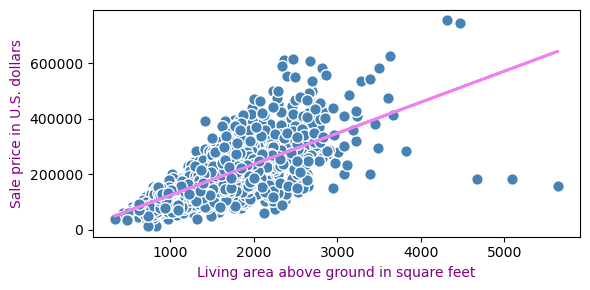

In [15]:
plt.figure(figsize=(6,3))
lin_regplot(X, y, slr)
plt.xlabel("Living area above ground in square feet", color='purple')
plt.ylabel("Sale price in U.S. dollars", color='purple')
plt.tight_layout()
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Let's add the other features to get the best predictions possible with a linear regression model. It will no more be possible to plot the linear regression line (it is now a 5d-hyperplane) to compare it with the true target values, so we will need other means to evaluate the quality of the model.<br>$\quad$
        In order to get more reliable evaluations of this quality, we separate the original dataset into a training and a test datasets, train a linear regression model on the training dataset, and evaluate its quality on the test dataset. As a first evaluation technique we will plot the differences between the predictions and the true target values in two diagrams, one for the training instances, and the other for the test instances :

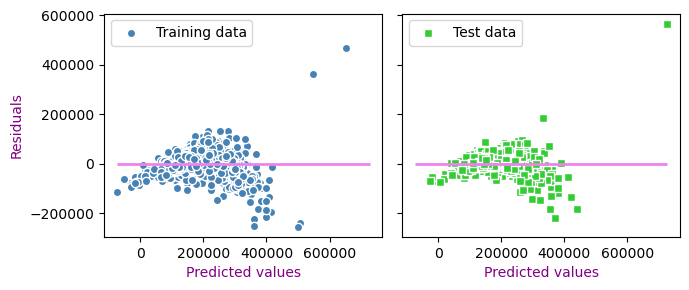

In [16]:
from sklearn.model_selection import train_test_split

target = 'SalePrice'
features = df_housing.columns[df_housing.columns != target]
X = df_housing[features].values
y = df_housing[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
slr = LinearRegression()
slr.fit(X_train, y_train)

y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
ax1.scatter(y_train_pred, y_train_pred - y_train, c='steelblue', marker='o', edgecolor='white',
            label='Training data')
ax2.scatter(y_test_pred, y_test_pred - y_test, c='limegreen', marker='s', edgecolor='white',
            label='Test data')
ax1.set_ylabel('Residuals', color='purple')
for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values', color='purple')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='violet', lw=2)
plt.tight_layout()
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Such diagrams are called <font color='darkpink'>residual plots</font>, a <font color='darkpink'>residual</font> being the difference between a predicted value and its corresponding true target value. The horizontal violet line (of equation $y=0$) represents the perfect predictions, the dots represent the instances' residuals. The isolated values far from the horizontal line are the <font color='darkpink'>outliers</font>.

<br><br><div style="font-family: Arial; font-size: 14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>2c. Quantitative evaluations of a model</font><a id="2c"></a></p>$\quad$
        In order to measure the performance of a model on a given dataset, we can use the mean of the square of the errors made on every instances of the dataset, aka the $MSE\,$ (see equation (2)), or the mean of the absolute values of these errors, aka the $MAE\,$ (see equation (3)), which is less sensitive to outliers.<br>$\quad$
        The models we have considered thus far have the following performances :

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# MSE of our basic linear regression model with only 1 feature; we used 50 epochs, so the MSE of the fully trained
# model is in the last entry of 'lr.losses_', 'lr.losses_[49]'
print(BB + "Our basic linear regression model with only 1 feature has an MSE of" + MB,
      round(lr.losses_[49],3), BB + "for the whole dataset.")

# MSE and MAE of scikit-learn's linear regression with only 1 feature
print(BB + "\nScikit-learn's linear regression with only 1 feature has an MSE of" + MB,
      "{:.3e}".format(mean_squared_error(y, y_pred)), BB + "for the whole dataset")
print(BB + "and an MAE of" + MB, "{:.3e}".format(mean_absolute_error(y, y_pred)), BB + "for the whole dataset.")

# MSE and MAE of scikit-learn's linear regression with 5 features on the training and test datasets
print(BB + "\nScikit-learn's linear regression with 5 features has an MSE of" + MB,
      "{:.3e}".format(mean_squared_error(y_train, y_train_pred)), BB + "for the training dataset")
print(BB + "and of" + MB, "{:.3e}".format(mean_squared_error(y_test, y_test_pred)), BB + "for the test dataset.")
print(BB + "Scikit-learn's linear regression with 5 features has an MAE of" + MB,
      "{:.3e}".format(mean_absolute_error(y_train, y_train_pred)), BB + "for the training dataset")
print(BB + "and of" + MB, "{:.3e}".format(mean_absolute_error(y_test, y_test_pred)), BB + "for the test dataset.")

Our basic linear regression model with only 1 feature has an MSE of 0.501 for the whole dataset.

Scikit-learn's linear regression with only 1 feature has an MSE of 3.193e+09 for the whole dataset
and an MAE of 3.854e+04 for the whole dataset.

Scikit-learn's linear regression with 5 features has an MSE of 1.497e+09 for the training dataset
and of 1.517e+09 for the test dataset.
Scikit-learn's linear regression with 5 features has an MAE of 2.598e+04 for the training dataset
and of 2.492e+04 for the test dataset.


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        From the $MSE\,$ and $MAE\,$ obtained for the linear regression with 5 features, we see that the model is generalizing quite well to unseen data (the test dataset) compared to its fit on the training dataset.<br>$\quad$
        From the comparison between the linear regression with 5 features and the linear regression with only 1, we see that linearly estimating the sale prices from 5 features does indeed yield better results than estimating them from 1 feature only.<br>$\quad$
        From the comparison between these results and the result obtained by our model with only 1 feature, we see that the $MSE\,$ (and it is true of the $MAE\,$ as well) are strongly dependent on the units used for the features, and if they have been standardized or not. They are useful indicators of performance between models built on exactly the same datasets only. If we want a measure of performance which does not depend on the units used for the features, we can use the <font color='darkpink'>coefficient of determination</font> (<font color='darkpink'>$R^2$</font>) :<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$R^2 \;=\; 1 - \frac{MSE}{\text{Var}(y)} \;=\; 1 - \frac{\sum_{i=1}^m \left( y^{(i)} - \hat{y}^{(i)} \right)^2}{\sum_{i=1}^m \left( y^{(i)} - \mu_y \right)^2} \qquad (11)$$</font>
    where $\mu_y$ is the mean of the target vector $y$ and $\text{Var}(y)$ is its variance, ie a strictly positive number which does not depend on the chosen model.<br>$\quad$
        The better the model, the lower its $MSE\,$, and thus the greater its coefficient of determination $R^2$. A model is perfect iff it estimates each target value perfectly, iff its $MSE\,$ is $0$, iff its coefficient of determination is $1$. Thus, in general, $R^2<1$. Also, if a model predicted each target value to be equal to the mean of the target vector (a random guess), then its coefficient of determination would be equal to $0$. Thus, in general, $R^2>0$.<br>
    To sum it up : <font color='darkpink'>The better the model, the higher its coefficient of determination $R^2$. A model is perfect iff $R^2=1$, while $R^2=0$ corresponds to the random model that predicts the mean of the true values for all instances.</font><br>$\quad$
    How high an $R^2$ value needs to be depends on the field. Some fields require higher precision than others. For example, in scientific studies, $R^2$ may need to be above $0.95$ for a regression model to be considered reliable; in other domains, an $R^2$ of just $0.3$ may be sufficient if there is extreme variability in the dataset.<br>$\quad$
        Let's compute the coefficients of determination of the models we have considered thus far :

In [18]:
from sklearn.metrics import r2_score

# in our basic implementation of the linear regression we had standardized the target vector, so its variance is 1
# and the coefficient of determination is simply 1-MSE
# '\u00B2' is the unicode for superscript 2
print(BB + "The R² of our basic linear regression model with only 1 feature is" + MB,
      round(1-lr.losses_[49],3), BB + "(where we used the whole dataset).\n")

print(BB + "The R² of the scikit-learn's linear regression model with only 1 feature is"\
      + MB, round(r2_score(y, y_pred),3), BB + "(where we used the whole dataset).\n")

print(BB + "The R² of the scikit-learn's linear regression model with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred),3), BB + "on the training dataset.")
print(BB + "The R² of the scikit-learn's linear regression model with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred),3), BB + "on the test dataset.")

The R² of our basic linear regression model with only 1 feature is 0.499 (where we used the whole dataset).

The R² of the scikit-learn's linear regression model with only 1 feature is 0.499 (where we used the whole dataset).

The R² of the scikit-learn's linear regression model with 5 features is 0.769 on the training dataset.
The R² of the scikit-learn's linear regression model with 5 features is 0.752 on the test dataset.


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        As expected, the coefficients of determination are the same when we estimate the sale prices linearly with one feature only (the ground living area), whether we use our basic implementation of the linear regression model or scikit-learn's implementation.<br>$\quad$
        Also, the coefficients of determination improve when we use 5 features rather than 1. While the results are not outstanding, we only used 5 features out of the original 80, and this under a simple linear regression.<br>$\quad$
        In the next chapter we will present other regression models.

<br><br><div style="font-family: Arial; font-size: 14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>2d. Regularized linear regression</font><a id="2d"></a></p>$\quad$
        As we have seen in part 3, "2g. Overfitting and regularized linear models", we can alleviate overfitting problems by regularizing our cost function, ie adding an $L^2$ or an $L^1$ (or a mix of both) penalty to our cost function $L$; more precisely, by replacing $L$ with the cost function :<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$Lr(w) \;=\;  L(w) \; + \: \frac{\lambda}{m} \sum_{j=1}^n w_j^2 \; + \: \frac{\mu}{m} \sum_{j=1}^n \lvert w_j \rvert \quad ; \; \lambda , \mu \geq 0 \qquad (12)$$</font>
    where $\lambda$ and $\mu$ are positive parameters that we can adjust.<br>$\quad$
        Regularized linear regression is called <font color='darkpink'>Ridge regression</font> when <font color='purple'>$\; \lambda>0 \;\text{ and }\; \mu=0\;$</font>, <font color='darkpink'>Lasso regression</font> when <font color='purple'>$\; \lambda=0 \;\text{ and }\; \mu>0\;$</font>, and <font color='darkpink'>Elastic net regression</font> when <font color='purple'>$\; \lambda>0 \;\text{ and }\; \mu>0\;$</font>.<br>$\quad$
        In (continuous) linear regression models we usually use the $MSE\,$ as the base cost function, so this equation becomes<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$Lr(w) \;=\;  \frac{1}{m} \, \sum_{i=1}^m \left( y^{(i)} - \hat{y}^{(i)} \right)^2 \; + \: \frac{\lambda}{m} \sum_{j=1}^n w_j^2 \; + \: \frac{\mu}{m} \sum_{j=1}^n \lvert w_j \rvert \quad ; \; \lambda , \mu \geq 0 \qquad (13)$$</font>

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        <font color='green'>scikit-learn</font> does not use consistent notations across all three regularized linear regression models :<br>
    * in the Ridge regression case they use a parameter <font color='green'>alpha</font> which is equal to the $\lambda$ in $(13)$<br>
    * in the Lasso regression case they use a parameter <font color='green'>alpha</font> which is $\alpha=\frac{\mu}{2m}$<br>
    * in the Elastic Net regression case they use two parameters, <font color='green'>alpha</font> and <font color='green'>l1_ratio</font> which are $\alpha= \frac{2\lambda+\mu}{2m}$ and $\text{l1\_ratio} = \frac{\mu}{2\lambda+\mu}$<br>$\quad$
        In our current example, there is almost no overfitting, so it is unlikely that a regularized cost function would yield better results; on the contrary, too much regularization would make the model underfit the data and our predictions would be worsened.<br>
    In the following code, I have tried the Ridge, the Lasso, and the Elastic Net regression models using <font color='green'>scikit-learn</font> and their default values, corresponding to $\,\lambda=1 \;\text{ and }\; \mu=0\,$, $\,\lambda=0 \;\text{ and }\; \mu=4100\,$ (since there are $2929$ instances in our initial matrix and we kept $70\%$ -ie $2050$- of them for our training dataset); and $\,\lambda=1025 \;\text{ and }\; \mu=2050\,$ respectively.<br>
    The coefficients of determination (our quantitative measure of the quality of a model, see "2c. Quantitative evaluations of a model") of the default Ridge and Lasso models are the same as the one obtained when we used the non-regularized $MSE\,$, but it is worse in the Elastic Net model, with underfitting (as shown by the worse results obtained on the training dataset).

In [19]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# creates a Ridge regression model with the regularization parameter (alpha) set to its default value,
# then trains it on the training dataset and make predictions on the training and test datasets
ridge_ = Ridge(alpha=1)
ridge_.fit(X_train, y_train)
y_train_rpred = ridge_.predict(X_train)
y_test_rpred = ridge_.predict(X_test)

# creates a Lasso regression model with the regularization parameter (alpha) set to its default value,
# then trains it on the training dataset and make predictions on the training and test datasets
lasso_ = Lasso(alpha=1)
lasso_.fit(X_train, y_train)
y_train_lpred = lasso_.predict(X_train)
y_test_lpred = lasso_.predict(X_test)

# creates an ElasticNet regression model with the regularization parameter (alpha) set to its default
# value, then trains it on the training dataset and make predictions on the training and test datasets
elastic_ = ElasticNet(alpha=1, l1_ratio=0.5)
elastic_.fit(X_train, y_train)
y_train_epred = elastic_.predict(X_train)
y_test_epred = elastic_.predict(X_test)

print(BB + "The R² of the Ridge linear regression model with 5 features is" + MB,
      round(r2_score(y_train, y_train_rpred),3), BB + "on the training dataset.")
print(BB + "The R² of the Ridge linear regression model with 5 features is" + MB,
      round(r2_score(y_test, y_test_rpred),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the Lasso linear regression model with 5 features is" + MB,
      round(r2_score(y_train, y_train_lpred),3), BB + "on the training dataset.")
print(BB + "The R² of the Lasso linear regression model with 5 features is" + MB,
      round(r2_score(y_test, y_test_lpred),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the Elastic Net linear regression model with 5 features is" + MB,
      round(r2_score(y_train, y_train_epred),3), BB + "on the training dataset.")
print(BB + "The R² of the Elastic Net linear regression model with 5 features is" + MB,
      round(r2_score(y_test, y_test_epred),3), BB + "on the test dataset.")

The R² of the Ridge linear regression model with 5 features is 0.769 on the training dataset.
The R² of the Ridge linear regression model with 5 features is 0.752 on the test dataset.

The R² of the Lasso linear regression model with 5 features is 0.769 on the training dataset.
The R² of the Lasso linear regression model with 5 features is 0.752 on the test dataset.

The R² of the Elastic Net linear regression model with 5 features is 0.757 on the training dataset.
The R² of the Elastic Net linear regression model with 5 features is 0.727 on the test dataset.


<br><br><div style="font-family: Arial; font-size: 14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>2e. Polynomial regression</font><a id="2e"></a></p>$\quad$
        In the book, the author explains what polynomial regression is, introduces the <font color='green'>scikit-learn</font> class <font color='green'>PolynomialFeatures(degree=2)</font>, which adds to a matrix all columns corresponding to the monomials of features of degree $\leq$<font color='green'>degree</font> (this class is part of <font color='green'>scikit-learn</font>'s <font color='green'>preprocessing</font> module), and concludes this subchapter with a comprehensive study of linear regression using only one feature.<br>$\quad$
        Since I have already explained what polynomial regression is (see Part 2, "2f. Polynomial Regression"), since the functionality of the <font color='green'>PolynomialFeatures</font> class is straightforward, since we have already demonstrated how to plot the regression line and instance points on a diagram (see "2a. A Basic Implementation of GD"), and since the results obtained by the author in this single-feature linear regression case are only marginally better despite removing three outliers (for previous results in this case, see "2c. Quantitative Evaluations of a Model"), I prefer to present the topic of polynomial regression in our current example, where we try to estimate the sale prices of houses using a selection of only 5 features from the original 80.<br>$\quad$
        First, I tried a polynomial regression of degree 2. We achieve much better results than with a simple linear regression, with a coefficient of determination of $0.849$ (instead of $0.769$) on the training dataset, and of $0.859$ (instead of $0.752$) on the test dataset.<br>$\quad$
        Then, I tried a polynomial regression of degree 3. We obtain an even better coefficient of determination on the training dataset ($0.873$), but a worse one on the test dataset ($0.79$), indicating overfitting. To address this, I added a regularization term, an Elastic Net, which converged slowly during optimization, even with feature standardization. Consequently, I needed to increase the number of iterations to $10,000$ from the default $1,000$. Neither Ridge nor Lasso regressions could provide better results. In the end, the results were no better than those obtained with the polynomial regression of degree 2, with coefficients of determination of $0.851$ and $0.858$ on the training and test datasets respectively.

In [20]:
from sklearn.preprocessing import PolynomialFeatures

# adds to X_train and X_test the monomials of degree <= 'degree' which are not of degree 1
pol_features = PolynomialFeatures(degree=2)
X_pol_train = pol_features.fit_transform(X_train)
X_pol_test = pol_features.transform(X_test)

# trains a linear regression model on the new training matrix
model_deg2 = LinearRegression()
model_deg2.fit(X_pol_train, y_train)

# predictions obtained for the training and test datasets
y_train_ppred = model_deg2.predict(X_pol_train)
y_test_ppred = model_deg2.predict(X_pol_test)

# prints the coefficients of determination, as an indication of the quality of our model
print(BB + "The R² of the polynomial regression model with 5 features is" + MB,
      round(r2_score(y_train, y_train_ppred),3), BB + "on the training dataset.")
print(BB + "The R² of the polynomial regression model with 5 features is" + MB,
      round(r2_score(y_test, y_test_ppred),3), BB + "on the test dataset.")

The R² of the polynomial regression model with 5 features is 0.849 on the training dataset.
The R² of the polynomial regression model with 5 features is 0.859 on the test dataset.


In [21]:
# adds to X_train and X_test the monomials of degree <= 'degree' which are not of degree 1
pol_features = PolynomialFeatures(degree=3)
X_pol_train = pol_features.fit_transform(X_train)
X_pol_test = pol_features.transform(X_test)

# trains a linear regression model on the new training matrix
model_deg3 = LinearRegression()
model_deg3.fit(X_pol_train, y_train)
# trains a pipeline with StandardScaler and ElasticNet
from sklearn.pipeline import make_pipeline
model_deg3_elastic = make_pipeline(StandardScaler(), ElasticNet(max_iter=10000, alpha=.1, l1_ratio=.1))
model_deg3_elastic.fit(X_pol_train, y_train)

# predictions obtained for the training and test datasets
y_train_pred_pdeg3 = model_deg3.predict(X_pol_train)
y_test_pred_pdeg3 = model_deg3.predict(X_pol_test)
y_train_pred_pdeg3E = model_deg3_elastic.predict(X_pol_train)
y_test_pred_pdeg3E = model_deg3_elastic.predict(X_pol_test)

# prints the coefficients of determination, as an indication of the quality of our model
print(BB + "The R² of the polynomial regression model (deg 3, no regularization) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_pdeg3),3), BB + "on the training dataset.")
print(BB + "The R² of the polynomial regression model (deg 3, no regularization) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_pdeg3),3), BB + "on the test dataset.")
print(BB + "\nThe R\² of the polynomial regression model (deg 3, Elastic Net) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_pdeg3E),3), BB + "on the training dataset.")
print(BB + "The R² of the polynomial regression model (deg 3, Elastic Net) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_pdeg3E),3), BB + "on the test dataset.")

The R² of the polynomial regression model (deg 3, no regularization) with 5 features is 0.873 on the training dataset.
The R² of the polynomial regression model (deg 3, no regularization) with 5 features is 0.79 on the test dataset.

The R\² of the polynomial regression model (deg 3, Elastic Net) with 5 features is 0.851 on the training dataset.
The R² of the polynomial regression model (deg 3, Elastic Net) with 5 features is 0.858 on the test dataset.


<a id="3"></a><br><br><br><div style="font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">
    <h4 style="margin: 0 0 .5rem 2rem; font-size: 18px; font-weight: 800"><font color='darkpink'>3. OTHER REGRESSION MODELS</font></h4>
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>3a. Non-linear relationships with decision trees</font><a id="3a"></a></p>$\quad$
        We have already studied decision trees and random forests in the case of classification tasks (see part 3, "4. Decision trees and random forests"), as well as decision trees that predict real numbers (see part 7, "4a. The Gradient Boosting's strategy", where the targets were the pseudo-residuals). Here, we use the impurity measures of the classification case, but we will adapt them - so they can be used in the continuous case - following what we did in part 7.<br>$\quad$
        The strategy used to train a decision tree when the target variable is continuous is the same as the one we followed in the discrete (finite) case : we start at the root of the tree and we split its content on the feature that results in the largest "information gain", then we repeat this splitting procedure at each node until reaching the leaves (ie the terminal nodes).<br>
    Again, in practice we will only use binary decision trees, ie trees where each parent has exactly $2$ children, and nodes will be split according to the best separating hyperplane perpendicular to one of our features. In this case, the information-gain between a parent and its (potential) children depends on the cardinality $N_p$ of the set of instances inside the parent dataset $D_p$, on the cardinalities $N_{left}$ and $N_{right}$ of the children datasets $D_{left}$ and $D_{right}$ and on an "$\,$<font color='darkpink'>impurity measure</font>$\,$", "$\,$<font color='darkpink'>$I$</font>$\,$", which is a function over all possible datasets; the information gain is given by<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$IG(D_p) \;=\; I(D_p) \,-\, \frac{N_{left}}{N_p} I(D_{left}) \,-\, \frac{N_{right}}{N_p} I(D_{right}) \qquad (14)$$</font><br>$\quad$
        The difference is that, while the impurity measures in the discrete case used the proportions of instances in the dataset belonging to each class, this is no longer possible in the continuous case, and the impurity measure of any dataset $D$ will be the variance of the target values of its instances : if $N_D$ is the number of instances in $D$ and if<br><p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$\hat{y}_D \;=\; \frac{1}{N_D} \;\sum_{x^{(i)} \in D}\, y^{(i)} \qquad (15)$$</font>
    is the mean of the target values of the instances in $D$, then the impurity measure of $D$ is<p style="margin: 0 0 .5rem 0"></p><font color = darkpink>
        $$I(D) \;=\; \frac{1}{N_D} \;\sum_{x^{(i)}\, \in D}\, \left(y^{(i)}-\hat{y}_D\right)^2 \qquad (16)$$

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        As an example, let's try to estimate the sale prices of housings from their ground living areas with a decision tree of depth $3$. In <font color='green'>scikit-learn</font> decision trees for estimating continuous variables are implemented in the <font color='green'>tree</font> module, alike decision trees for classification tasks, but instead of <font color='green'>DecisionTreeClassifier</font> we use the <font color='green'>DecisionTreeRegressor</font> class.<br>
    First we represent the data points together with the decision tree predictions and then we compute its coefficient of determination $R^2$ :

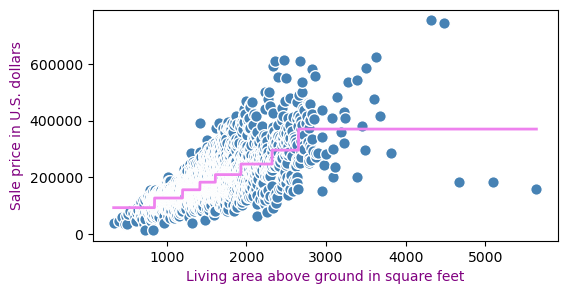

In [22]:
from sklearn.tree import DecisionTreeRegressor

X_1 = df_housing[["Gr Liv Area"]].values
y = df_housing["SalePrice"].values

tree_d3 = DecisionTreeRegressor(max_depth=3)
tree_d3.fit(X_1, y)

plt.figure(figsize=(6,3))
# the '.argsort()' method returns the indices that would sort an array in ascending order, so 'sort_idx' is the
# list of indices which corresponds to increasing x (ground living areas)
sort_idx = X_1.flatten().argsort()
lin_regplot(X_1[sort_idx], y[sort_idx], tree_d3)
plt.xlabel("Living area above ground in square feet", color='purple')
plt.ylabel("Sale price in U.S. dollars", color='purple')
plt.show()

In [23]:
y_td3pred = tree_d3.predict(X_1)
print(BB + "The R² of the decision tree of depth 3 with only 1 feature is" + MB,
      round(r2_score(y, y_td3pred),3), BB + "on the whole dataset.")

The R² of the decision tree of depth 3 with only 1 feature is 0.514 on the whole dataset.


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        The decision tree of depth $3$ has a coefficient of determination of $0.514$, which is slightly better than the regression lines we obtained in "2a. A basic implementation of GD" and in "2b. Scikit-learn's 'LinearRegression'", which both had an $R^2$ of $0.499$ (see "2c. Quantitative evaluations of a model"). However deeper decision trees will get better $R^2$; the best $R^2$ we can obtain is $0.819$, when we do not limit the tree's depth, which is the default in <font color='green'>scikit-learn</font>. Let's compute this result and show the corresponding diagram in the case <font color='green'>max_depth=None</font> :

The R² of the decision tree with only 1 feature is 0.819 on the whole dataset.


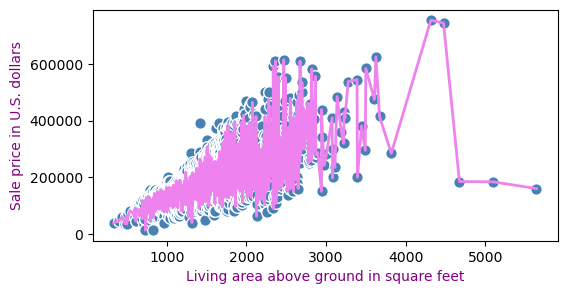

In [24]:
tree = DecisionTreeRegressor()
tree.fit(X_1, y)
y_tpred = tree.predict(X_1)
print(BB + "The R² of the decision tree with only 1 feature is" + MB,
      round(r2_score(y, y_tpred),3), BB + "on the whole dataset.")
plt.figure(figsize=(6,3))
sort_idx = X_1.flatten().argsort()
lin_regplot(X_1[sort_idx], y[sort_idx], tree)
plt.xlabel("Living area above ground in square feet", color='purple')
plt.ylabel("Sale price in U.S. dollars", color='purple')
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        These excellent results are clearly due to a huge amount of overfitting. The predictions capabilities of this tree are much worse than the ones from the tree of depth $3$. More precisely, if we train a tree with <font color='green'>max_depth=3</font> and a tree with <font color='green'>max_depth=None</font> on a training dataset (containing $70\%$ of the whole dataset), we get an $R^2$ on the training dataset of $0.518$ and $0.857$ respectively, but on the test dataset their $R^2$ is of $0.48$ and $0.134$ :

In [25]:
tree_d3 = DecisionTreeRegressor(max_depth=3)
tree = DecisionTreeRegressor()

X_1_train, X_1_test, y_train, y_test = train_test_split(X_1, y, test_size=0.3, random_state=123)
tree_d3.fit(X_1_train, y_train)
tree.fit(X_1_train, y_train)

# predictions obtained for the training and test datasets
y_train_td3pred = tree_d3.predict(X_1_train)
y_test_td3pred = tree_d3.predict(X_1_test)
y_train_tpred = tree.predict(X_1_train)
y_test_tpred = tree.predict(X_1_test)

print(BB + "The R² of the decision tree of depth 3 with 1 feature is" + MB,
      round(r2_score(y_train, y_train_td3pred),3), BB + "on the training dataset.")
print(BB + "The R² of the decision tree of depth 3 with 1 feature is" + MB,
      round(r2_score(y_test, y_test_td3pred),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the decision tree with no maximum depth with 1 feature is" + MB,
      round(r2_score(y_train, y_train_tpred),3), BB + "on the training dataset.")
print(BB + "The R² of the decision tree with no maximum depth with 1 feature is" + MB,
      round(r2_score(y_test, y_test_tpred),3), BB + "on the test dataset.")

The R² of the decision tree of depth 3 with 1 feature is 0.518 on the training dataset.
The R² of the decision tree of depth 3 with 1 feature is 0.48 on the test dataset.

The R² of the decision tree with no maximum depth with 1 feature is 0.857 on the training dataset.
The R² of the decision tree with no maximum depth with 1 feature is 0.134 on the test dataset.


<br><br><div style="font-family: Arial; font-size: 14px; color: darkblue">
    <p style="margin: 0 0 .5rem 4rem; font-size: 16px; font-weight: 600"><font color='darkpink'>3b. Non-linear relationships with random forests</font><a id="3b"></a></p>$\quad$
        As in the classification tasks, the right way to improve predictions is not to better fit a single tree (as seen in the previous subchapter, this leads to overfitting and worse predictive capabilities), but to use many simple trees instead of 1, ie to use a <font color='darkpink'>random forest</font>. And to use more features as well, obviously.<br>$\quad$
        In <font color='green'>scikit-learn</font>, the class for random forests in the continuous case is called <font color='green'>RandomForestRegressor</font>; alike <font color='green'>RandomForestClassifier</font> for classification tasks, it is implemented in the <font color='green'>ensemble</font> module. One advantage of random forests is that they don’t require much parameter tuning. The only parameter in random forests that we typically need to experiment with is the number of trees in the ensemble and the <font color='green'>max_depth</font> of the simple trees. By default, scikit-learn uses <font color='green'>n_estimators=$100$</font> decision trees with <font color='green'>max_depth=None</font>.<br>$\quad$
        As an example the author uses $1000$ decision trees with <font color='green'>max_depth=None</font>. But in fact using $1000$ decision trees instead of $100$ does not change the quality of predictions, neither on the training dataset nor on the test dataset, as my results below demonstrate. The hyperparameter which does change something, though, is the depth of the trees and the number of selected features.<br>
    When we select only 1 feature, the quality of predictions - as measured with the coefficient of determination $R^2$ - is still bad with random forests - only marginally better than with a single tree ($0.53$ vs $0.518$ on the training dataset, and $0.494$ vs $0.48$ on the test dataset, both with trees of depth $3$) -, and there is still huge overfitting -although less so - when using trees with <font color='green'>max_depth=None</font> (with an $R^2$ of $0.808$ on the training dataset and of $0.311$ on the test dataset).<br>
    When we use 5 features, the quality of predictions is comparable to what we obtained with a simple linear regression when we use trees of depth $3$, but much better and comparable to what we obtained with polynomial regression of degree $2$ when we use <font color='green'>max_depth=None</font>. Note that in this later case, there is still overfitting : the $R^2$ of the predictions on the training dataset is excellent, with $0.975$, although it is slightly not as good as it was with the polynomial regression of degree $2$ on the test dataset ($0.848$ vs $0.859$).

In [26]:
from sklearn.ensemble import RandomForestRegressor

forest_1_100_d3 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=1, n_jobs=-1)
forest_1_1000_d3 = RandomForestRegressor(n_estimators=1000, max_depth=3, random_state=1, n_jobs=-1)
forest_1_100_nmd = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=1, n_jobs=-1)
forest_1_1000_nmd = RandomForestRegressor(n_estimators=1000, max_depth=None, random_state=1, n_jobs=-1)

forest_1_100_d3.fit(X_1_train, y_train)
y_train_pred_1_100_d3 = forest_1_100_d3.predict(X_1_train)
y_test_pred_1_100_d3 = forest_1_100_d3.predict(X_1_test)
forest_1_1000_d3.fit(X_1_train, y_train)
y_train_pred_1_1000_d3 = forest_1_1000_d3.predict(X_1_train)
y_test_pred_1_1000_d3 = forest_1_1000_d3.predict(X_1_test)
forest_1_100_nmd.fit(X_1_train, y_train)
y_train_pred_1_100_nmd = forest_1_100_nmd.predict(X_1_train)
y_test_pred_1_100_nmd = forest_1_100_nmd.predict(X_1_test)
forest_1_1000_nmd.fit(X_1_train, y_train)
y_train_pred_1_1000_nmd = forest_1_1000_nmd.predict(X_1_train)
y_test_pred_1_1000_nmd = forest_1_1000_nmd.predict(X_1_test)

print(BB + "The R² of the random forest (100 trees of depth 3) with 1 feature is" + MB,
      round(r2_score(y_train, y_train_pred_1_100_d3),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (100 trees of depth 3) with 1 feature is" + MB,
      round(r2_score(y_test, y_test_pred_1_100_d3),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (1000 trees of depth 3) with 1 feature is" + MB,
      round(r2_score(y_train, y_train_pred_1_1000_d3),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (1000 trees of depth 3) with 1 feature is" + MB,
      round(r2_score(y_test, y_test_pred_1_1000_d3),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (100 trees with no maximum depth) with 1 feature is" + MB,
      round(r2_score(y_train, y_train_pred_1_100_nmd),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (100 trees with no maximum depth) with 1 feature is" + MB,
      round(r2_score(y_test, y_test_pred_1_100_nmd),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (1000 trees with no maximum depth) with 1 feature is" + MB,
      round(r2_score(y_train, y_train_pred_1_1000_nmd),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (1000 trees with no maximum depth) with 1 feature is" + MB,
      round(r2_score(y_test, y_test_pred_1_1000_nmd),3), BB + "on the test dataset.")

The R² of the random forest (100 trees of depth 3) with 1 feature is 0.53 on the training dataset.
The R² of the random forest (100 trees of depth 3) with 1 feature is 0.494 on the test dataset.

The R² of the random forest (1000 trees of depth 3) with 1 feature is 0.531 on the training dataset.
The R² of the random forest (1000 trees of depth 3) with 1 feature is 0.497 on the test dataset.

The R² of the random forest (100 trees with no maximum depth) with 1 feature is 0.808 on the training dataset.
The R² of the random forest (100 trees with no maximum depth) with 1 feature is 0.311 on the test dataset.

The R² of the random forest (1000 trees with no maximum depth) with 1 feature is 0.811 on the training dataset.
The R² of the random forest (1000 trees with no maximum depth) with 1 feature is 0.31 on the test dataset.


In [27]:
forest_5_100_d3 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=1, n_jobs=-1)
forest_5_1000_d3 = RandomForestRegressor(n_estimators=1000, max_depth=3, random_state=1, n_jobs=-1)
forest_5_100_nmd = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=1, n_jobs=-1)
forest_5_1000_nmd = RandomForestRegressor(n_estimators=1000, max_depth=None, random_state=1, n_jobs=-1)

forest_5_100_d3.fit(X_train, y_train)
y_train_pred_5_100_d3 = forest_5_100_d3.predict(X_train)
y_test_pred_5_100_d3 = forest_5_100_d3.predict(X_test)
forest_5_1000_d3.fit(X_train, y_train)
y_train_pred_5_1000_d3 = forest_5_1000_d3.predict(X_train)
y_test_pred_5_1000_d3 = forest_5_1000_d3.predict(X_test)
forest_5_100_nmd.fit(X_train, y_train)
y_train_pred_5_100_nmd = forest_5_100_nmd.predict(X_train)
y_test_pred_5_100_nmd = forest_5_100_nmd.predict(X_test)
forest_5_1000_nmd.fit(X_train, y_train)
y_train_pred_5_1000_nmd = forest_5_1000_nmd.predict(X_train)
y_test_pred_5_1000_nmd = forest_5_1000_nmd.predict(X_test)

print(BB + "The R² of the random forest (100 trees of depth 3) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_5_100_d3),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (100 trees of depth 3) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_5_100_d3),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (1000 trees of depth 3) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_5_1000_d3),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (1000 trees of depth 3) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_5_1000_d3),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (100 trees with no maximum depth) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_5_100_nmd),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (100 trees with no maximum depth) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_5_100_nmd),3), BB + "on the test dataset.")
print(BB + "\nThe R² of the random forest (1000 trees with no maximum depth) with 5 features is" + MB,
      round(r2_score(y_train, y_train_pred_5_1000_nmd),3), BB + "on the training dataset.")
print(BB + "The R² of the random forest (1000 trees with no maximum depth) with 5 features is" + MB,
      round(r2_score(y_test, y_test_pred_5_1000_nmd),3), BB + "on the test dataset.")

The R² of the random forest (100 trees of depth 3) with 5 features is 0.789 on the training dataset.
The R² of the random forest (100 trees of depth 3) with 5 features is 0.793 on the test dataset.

The R² of the random forest (1000 trees of depth 3) with 5 features is 0.787 on the training dataset.
The R² of the random forest (1000 trees of depth 3) with 5 features is 0.789 on the test dataset.

The R² of the random forest (100 trees with no maximum depth) with 5 features is 0.975 on the training dataset.
The R² of the random forest (100 trees with no maximum depth) with 5 features is 0.848 on the test dataset.

The R² of the random forest (1000 trees with no maximum depth) with 5 features is 0.976 on the training dataset.
The R² of the random forest (1000 trees with no maximum depth) with 5 features is 0.847 on the test dataset.


<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Alike what we did in "2b. Scikit-learn's 'LinearRegression'" for the linear regression model's residuals (cell 16), we can now plot the residuals for the random forest ($1000$ trees with no maximum depth) when we use 5 features to evaluate the sale prices of the housings :

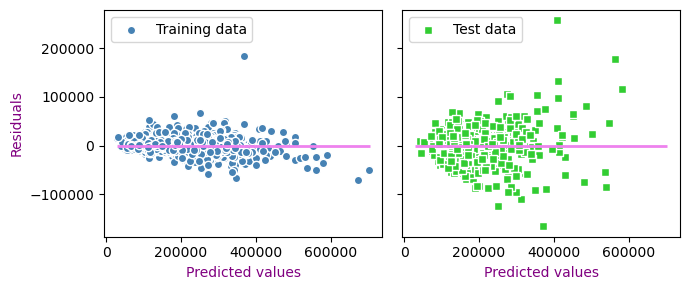

In [28]:
x_max = np.max([np.max(y_train_pred_5_1000_nmd), np.max(y_test_pred_5_1000_nmd)])
x_min = np.min([np.min(y_train_pred_5_1000_nmd), np.min(y_test_pred_5_1000_nmd)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
ax1.scatter(y_train_pred_5_1000_nmd, y_train_pred_5_1000_nmd - y_train, c='steelblue', marker='o',
            edgecolor='white', label='Training data')
ax2.scatter(y_test_pred_5_1000_nmd, y_test_pred_5_1000_nmd - y_test, c='limegreen', marker='s',
            edgecolor='white', label='Test data')
ax1.set_ylabel('Residuals', color='purple')
for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values', color='purple')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='violet', lw=2)
plt.tight_layout()
plt.show()

<br><div style="margin: 0; font-family: Arial; font-size: 14px; font-weight: 500; color: darkblue">$\quad$
        Ideally, our model errors should be random, unpredictable. In particular the residuals plot should show no pattern. But here, "the distribution of the residuals does not seem to be completely random around the zero center point". This indicates that there is still some relationship between the data points that remains to be discovered.<br>$\quad$
        "Unfortunately, there is not a universal approach for dealing with non-randomness in residual plots, and it requires experimentation. Depending on the data that is available to us, we may be able to improve the model by transforming variables, tuning the hyperparameters of the learning algorithm, choosing simpler or more complex models, removing outliers, or including additional variables."